# 07 — scratch

**Summary.** An empty bench with everything already loaded and every baseline already in scope. This
notebook is meant to be edited; the other seven are meant to be read.

The loader is `kusama.py` next door. Its contract: **read, do not recompute.** If you find yourself
writing a kNN, a sha256 dedupe or a tokenizer here, there is already one in TypeScript and a second
one will quietly disagree with it.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd()))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import kusama as k

m = k.load_manifest()          # 20,000 manifest rows, 21 columns
X, order = k.load_clip()       # (19791, 512) unit vectors, row i == embedding_row i
knn = k.load_knn()             # 395,820 rows: 19,791 images x k=20
b = k.band()                   # min 0.1555 median 0.6428 max 0.9685
print("everything loaded. baselines:")
print(f"  two random works share a museum   {k.museum_chance():.4f}")
print(f"  two random works sit at cosine    {b['median']:.4f}")
print(f"  corpus 2D share                   {(m.dimensionality=='2d').mean():.4f}")
print(f"  a k-of-n group at chance          k.chance(k, n)")

everything loaded. baselines:
  two random works share a museum   0.3897
  two random works sit at cosine    0.6428
  corpus 2D share                   0.1465
  a k-of-n group at chance          k.chance(k, n)


## Things that are already here

| you want | call |
|---|---|
| a phrase in CLIP space | `k.load_text_tower(["..."])` |
| an influence set | `k.load_influences("withheld")`, ids from `k.influence_ids()` |
| a run's plates | `k.load_trajectory("out/condition-withheld")`, dirs from `k.trajectory_dirs()` |
| one picture | `k.thumb(sha256, size=96)` |
| a contact sheet | `k.thumb_grid(sha_list, cols=8)` |
| a CLI measurement with no export | `k.run_cli("surface")` |
| a number with its baseline | `k.Reading(name, value, baseline)` |

Write scratch files to `notebooks/out/` — it is gitignored. Do not write into `corpus/`, `out/` or
`.models/`; those are inputs and a notebook that edits its inputs is not reproducible.

scratch dir: /Users/jaycewalzer/kusama/notebooks/out


        id museum                             classification                                                                                                                     title
 met-72831    met                                   Stencils                                                                                                                (untitled)
 cma-95681    cma                                     Velvet                                                                                                            Velvet Segment
 cma-98504    cma                                     Velvet                                                                                                    Velvet with gold discs
 aic-66549    aic   gelatin silver (developing-out-paper) pr                                                                                           Hedge and Grasses - Lake George
 met-13839    met                              Printed piece                         

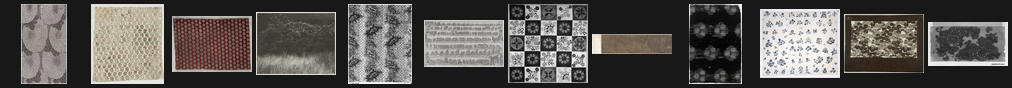

In [2]:
k.OUT.mkdir(exist_ok=True)
print("scratch dir:", k.OUT)

# example: a phrase, its nearest corpus works, and whether that is more than chance
q = k.load_text_tower("a field of dots")[0]
s = X @ q
top = np.argsort(-s)[:12]
kept = m[m.embedding_row.notna()].sort_values("embedding_row").reset_index(drop=True)
print(kept.iloc[top][["id", "museum", "classification", "title"]].to_string(index=False))
print(k.Reading("museums among the top 12",
                float(kept.iloc[top].museum.value_counts(normalize=True).max()),
                float(m.museum.value_counts(normalize=True).max())))
display(k.thumb_grid([order[i] for i in top], cols=12, size=80))

## Scratch

In [3]:
# yours